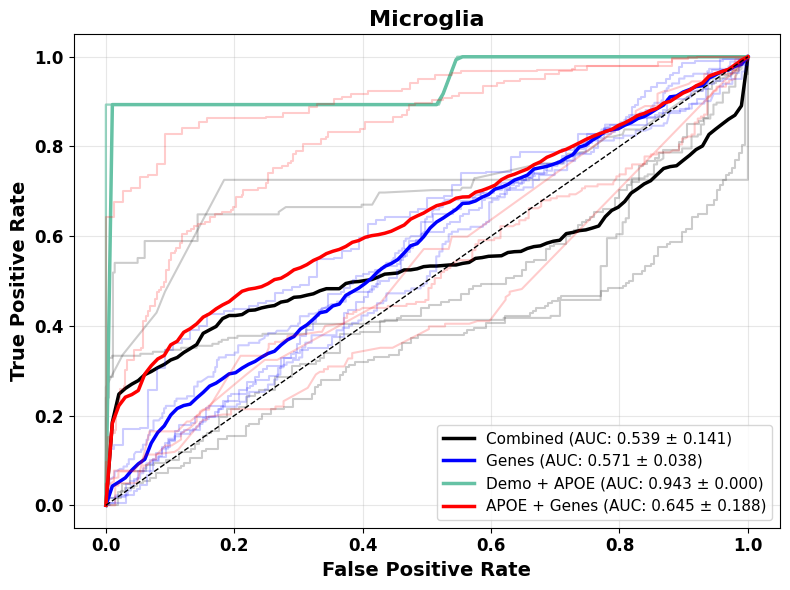

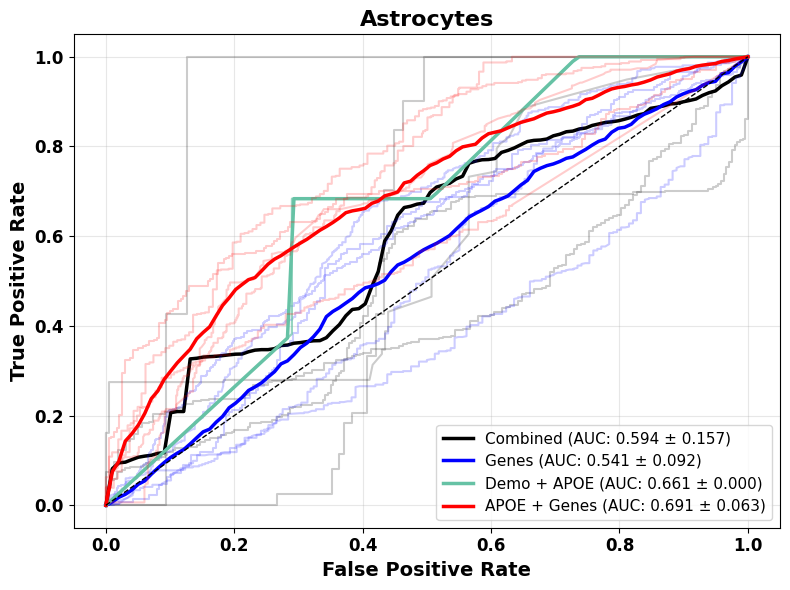

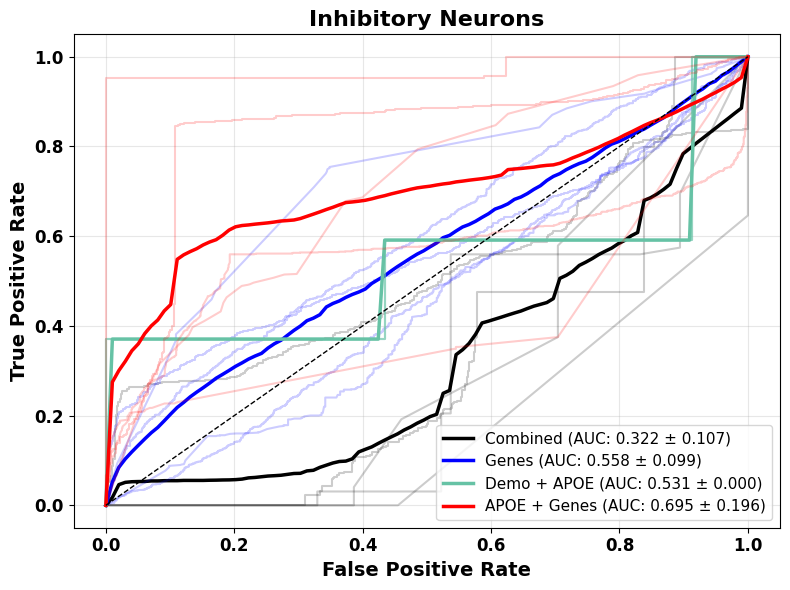

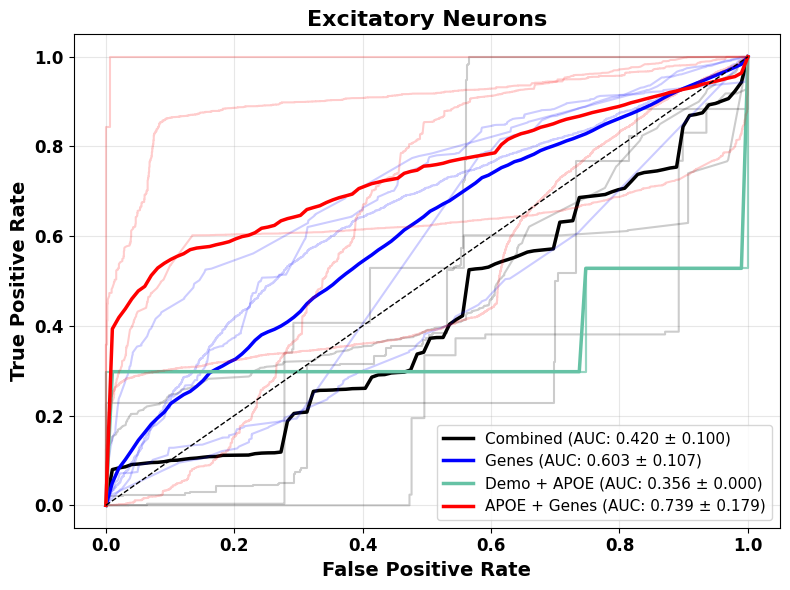

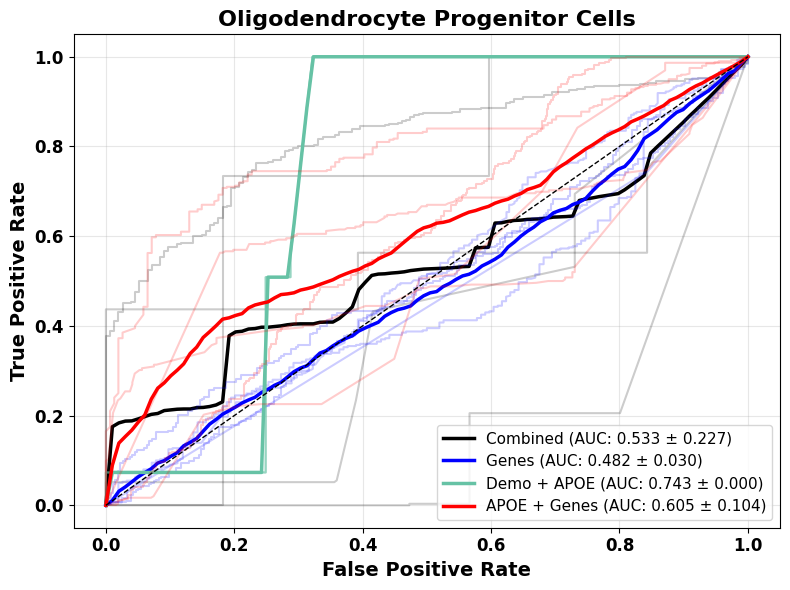

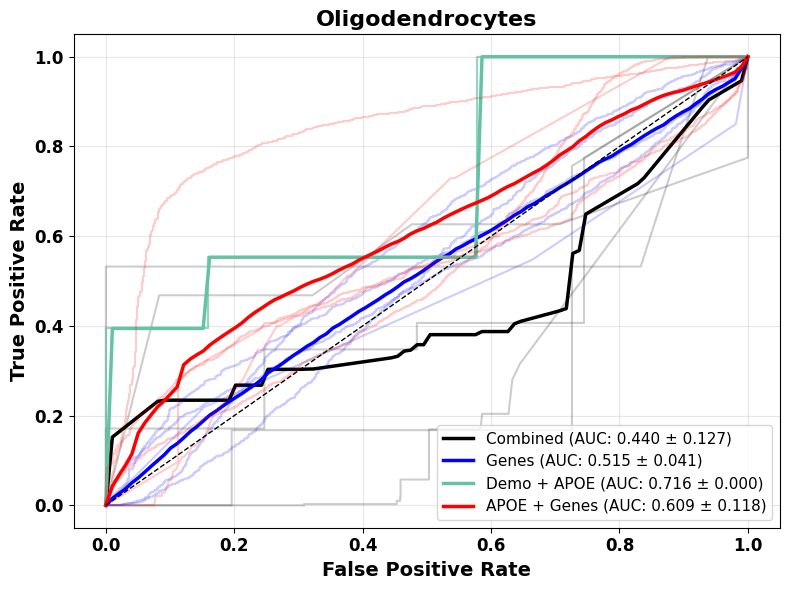

In [2]:
# import os
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_curve, auc

# def plot_roc_curves_with_variability(cell_type, cell_name):
#     base_dirs = {
#         'Combined': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_both_cerad/{cell_type}',
#         'Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad/{cell_type}',
#         'Demo + APOE': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_demo_cerad/{cell_type}',
#         'APOE + Genes': f'/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_apoe_cerad/{cell_type}',
#     }

#     colors = {
#         'Combined': 'black',
#         'Genes': 'blue',
#         'Demo + APOE': '#66c2a5',
#         'APOE + Genes': 'red',
#     }

#     plt.figure(figsize=(8, 6))
#     mean_fpr = np.linspace(0, 1, 100)

#     for label, base_path in base_dirs.items():
#         all_tprs = []
#         aucs = []

#         for i in range(1, 6):
#             pred_file = os.path.join(base_path, f'split_{i}', 'test_predictions.csv')
#             if not os.path.exists(pred_file):
#                 continue

#             df = pd.read_csv(pred_file)
#             y_true = df['true_label']
#             y_score = df['predicted_proba']
#             fpr, tpr, _ = roc_curve(y_true, y_score)
#             interp_tpr = np.interp(mean_fpr, fpr, tpr)
#             interp_tpr[0] = 0.0
#             all_tprs.append(interp_tpr)
#             aucs.append(auc(fpr, tpr))

#             plt.plot(fpr, tpr, color=colors[label], alpha=0.2)

#         if all_tprs:
#             mean_tpr = np.mean(all_tprs, axis=0)
#             mean_auc = np.mean(aucs)
#             std_auc = np.std(aucs)
#             plt.plot(mean_fpr, mean_tpr, color=colors[label], linewidth=2.5,
#                      label=f'{label} (AUC: {mean_auc:.3f} ± {std_auc:.3f})')

#     plt.plot([0, 1], [0, 1], 'k--', lw=1)
#     plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
#     plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
#     plt.title(cell_name, fontsize=16, fontweight='bold')
#     plt.xticks(fontsize=12, fontweight='bold')
#     plt.yticks(fontsize=12, fontweight='bold')
#     plt.legend(loc='lower right', fontsize=11, frameon=True)
#     plt.grid(alpha=0.3)
#     plt.tight_layout()

#     # Save figure
#     save_dir = f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4"
#     os.makedirs(save_dir, exist_ok=True)
#     output_path = os.path.join(save_dir, f'{cell_type}_roc_curve.png')
#     plt.savefig(output_path, dpi=300)
#     plt.show()

# plot_roc_curves_with_variability('Mic', 'Microglia')
# plot_roc_curves_with_variability('Ast', 'Astrocytes')
# plot_roc_curves_with_variability('In', 'Inhibitory Neurons')
# plot_roc_curves_with_variability('Ex', 'Excitatory Neurons')
# plot_roc_curves_with_variability('Opc', 'Oligodendrocyte Progenitor Cells')
# plot_roc_curves_with_variability('Oli', 'Oligodendrocytes')

/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

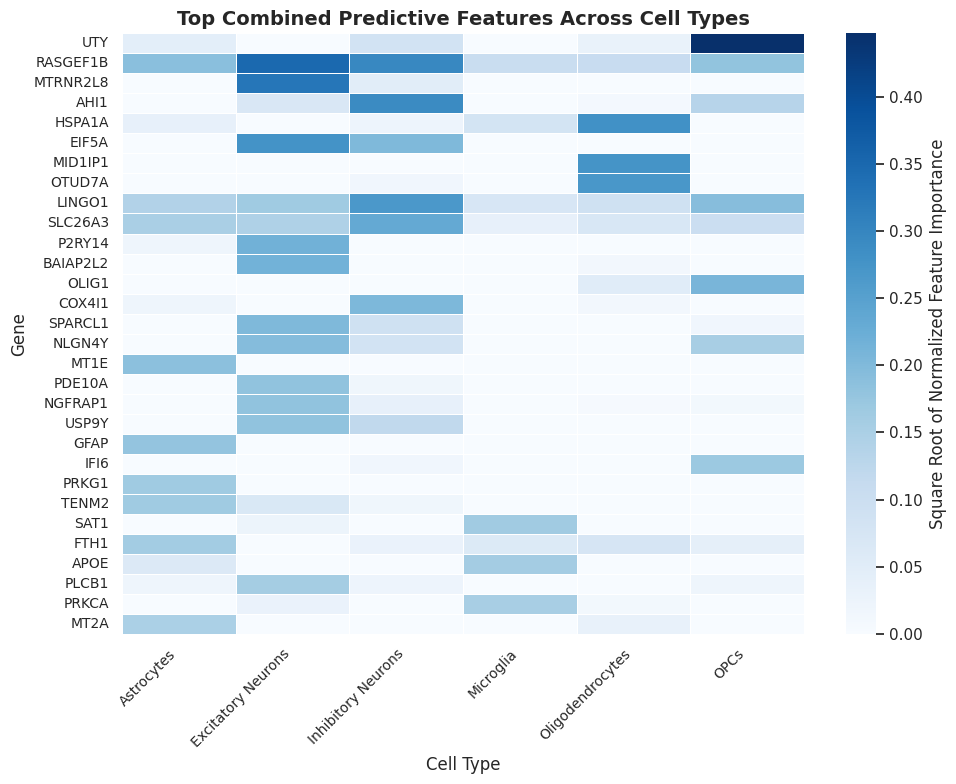

In [7]:
# import os
# import joblib
# import numpy as np
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# from collections import defaultdict

# # Set paths
# model_base_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
# save_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/feature_importance_heatmap_top30_just_genes.png"


# # Pretty cell type labels
# cell_types = {
#     "Ast": "Astrocytes",
#     "Ex": "Excitatory Neurons",
#     "In": "Inhibitory Neurons",
#     "Mic": "Microglia",
#     "Oli": "Oligodendrocytes",
#     "Opc": "OPCs"
# }

# # Feature renaming dictionary
# pretty_names = {
#     "age_death": "Age of Death",
#     "educ": "Education",
#     "msex": "Sex",
#     "apoe_genotype_230": "APOE ε2/3",
#     "apoe_genotype_330": "APOE ε3/3",
#     "apoe_genotype_340": "APOE ε3/4",
#     "apoe_genotype_440": "APOE ε4/4",
# }

# # Step 1: Collect importances per cell type
# importance_dict = {}

# for short, pretty in cell_types.items():
#     feature_data = defaultdict(list)
#     missing_splits = []
#     for i in range(1, 6):
#         model_path = os.path.join(model_base_path, short, f'split_{i}', 'maximal_classifier.joblib')
#         if not os.path.exists(model_path):
#             continue

#         model = joblib.load(model_path)
#         feature_names = np.array(model.feature_names_in_)
#         importances = model.feature_importances_

#         nonzero_mask = importances != 0
#         feature_names = feature_names[nonzero_mask]
#         importances = importances[nonzero_mask]
#         normalized = importances / np.sum(importances)

#         for feat, score in zip(feature_names, normalized):
#             feature_data[feat].append(score)
#     if missing_splits:
#         print(f"Missing splits for {pretty} ({short}): {missing_splits}")

#     # Pad each feature's list to length 5 (adding zeros if feature not present in some splits)
#     for feat in feature_data:
#         while len(feature_data[feat]) < 5:
#             feature_data[feat].append(0.0)

#     mean_importances = {feat: np.mean(vals) for feat, vals in feature_data.items()}
#     importance_dict[pretty] = mean_importances

# # Step 2: Construct DataFrame
# all_features = set()
# for cell_imp in importance_dict.values():
#     all_features.update(cell_imp.keys())

# df = pd.DataFrame(index=list(all_features), columns=list(cell_types.values())).fillna(0)
# for cell, feats in importance_dict.items():
#     for feat, val in feats.items():
#         df.loc[feat, cell] = val

# # Step 3: Pick top 20 features (by max importance in any cell type)
# # Step 3: Filter features present (non-zero) in at least 2 different cell types
# nonzero_counts = (df > 0).sum(axis=1)
# df_filtered = df[nonzero_counts >= 1]

# # Now pick top 30 based on max importance across cell types
# # Step 3: Filter features present (non-zero) in at least 1 cell type
# nonzero_counts = (df > 0).sum(axis=1)
# df_filtered = df[nonzero_counts >= 1]

# # Now pick top 30 based on mean importance across cell types
# top_30_feats = df_filtered.mean(axis=1).nlargest(30).index
# df_top30 = df_filtered.loc[top_30_feats]
# df_top30 = np.sqrt(df_top30)

# # Step 4: Rename features for clarity
# df_top30.index = [pretty_names.get(f, f) for f in df_top30.index]

# # Step 5: Plot
# plt.figure(figsize=(10, 8))
# sns.set(style="whitegrid")

# ax = sns.heatmap(df_top20, cmap="Blues", linewidths=0.5,
#                  cbar_kws={"label": "Square Root of Normalized Feature Importance"},
#                  xticklabels=True, yticklabels=True)

# plt.title("Top Combined Predictive Features Across Cell Types", fontsize=14, fontweight='bold')
# plt.xlabel("Cell Type", fontsize=12)
# plt.ylabel("Gene", fontsize=12)
# plt.xticks(fontsize=10, rotation=45, ha="right")
# plt.yticks(fontsize=10)
# plt.tight_layout()

# # Save clean version
# os.makedirs(os.path.dirname(save_path), exist_ok=True)
# plt.savefig(save_path, dpi=600, bbox_inches="tight")
# plt.show()


Processing Ast...


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

  Overlap genes: 29

Processing Mic...


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

  Overlap genes: 17

Processing In...


...

  Overlap genes: 7

Processing Ex...


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

  Overlap genes: 8


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

<Figure size 1000x600 with 0 Axes>

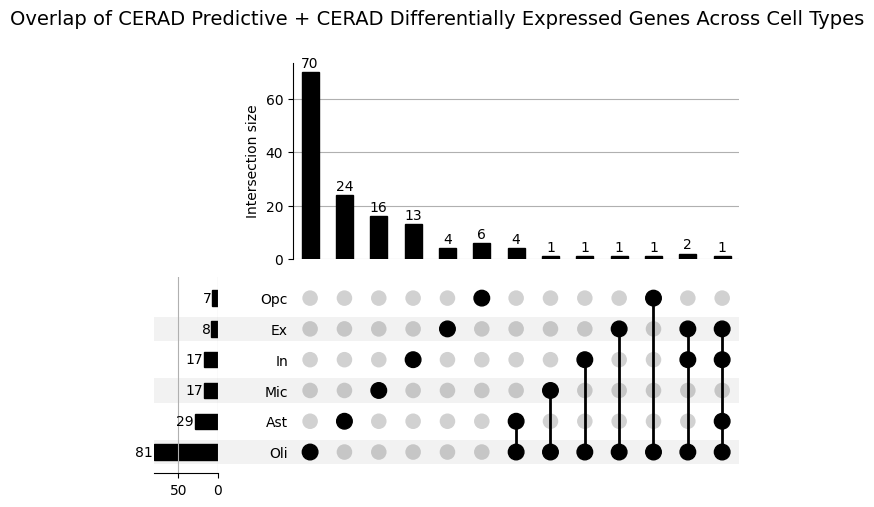


 UpSet plot saved to: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure4/cerad_upset_overlap_plot.png


In [1]:
# upset plot
import os
import pandas as pd
import joblib
from collections import defaultdict
from matplotlib import pyplot as plt
from upsetplot import from_contents, UpSet
# reran aug 11th

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
de_base_dir = "/n/scratch/users/a/adm808/Revision/Cerad_batch_DE_Outputs_revision"
out_fig_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure4/cerad_upset_overlap_plot.png"

# === Cell types ===
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]

# === DE result files ===
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Initialize dictionaries to store gene sets ===
predictive_de_overlap_dict = {}

# === Loop through each cell type ===
for cell_type_short in cell_types:
    print(f"\nProcessing {cell_type_short}...")

    # --- Predictive genes from model ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_
        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {gene for gene, count in gene_presence.items() if count >= 2}

    # --- Differentially expressed genes (p_adj < 0.05 only) ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull()]
    df["gene_upper"] = df["gene"].str.upper()

    # de_genes = set(df[df["p_adj"] < 0.05]["gene_upper"])
    de_genes = set(df[(df["p_adj"] < 0.05) & (df["log2FC"].abs() > 0.25)]["gene_upper"])

    # --- Overlap ---
    overlap_genes = predictive_genes & de_genes
    predictive_de_overlap_dict[cell_type_short] = overlap_genes
    print(f"  Overlap genes: {len(overlap_genes)}")

# === Create UpSet plot ===
contents = {k: v for k, v in predictive_de_overlap_dict.items() if len(v) > 0}

upset_data = from_contents(contents)
plt.figure(figsize=(10, 6))
upset = UpSet(upset_data, subset_size='count', show_counts=True, sort_by='degree')
upset.plot()

# === annotate small intersections ===
# find the Axes that has the bar chart

plt.suptitle("Overlap of CERAD Predictive + CERAD Differentially Expressed Genes Across Cell Types", fontsize=14)
plt.savefig(out_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n UpSet plot saved to: {out_fig_path}")

In [4]:
import os
import joblib
from collections import defaultdict

# Define base path and cell types
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# Dictionary to hold final predictors
predictive_genes_dict = {}

for cell_type in cell_types:
    print(f"Processing: {cell_type}")
    gene_presence = defaultdict(int)

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene] += 1

    # Keep genes that are non-zero in ≥ 3 splits
    final_predictors = [gene for gene, count in gene_presence.items() if count >= 2]
    predictive_genes_dict[cell_type] = final_predictors
    print(f"{cell_type}: {len(final_predictors)} predictive genes")

# This dictionary can now be used as your new top_25_dict equivalent
ad_predictors = predictive_genes_dict


import os
import joblib
from collections import defaultdict

# Define base path and cell types
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# Dictionary to hold final predictors
predictive_genes_dict_1 = {}

for cell_type in cell_types:
    print(f"Processing: {cell_type}")
    gene_presence = defaultdict(int)

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene] += 1

    # Keep genes that are non-zero in ≥ 3 splits
    final_predictors = [gene for gene, count in gene_presence.items() if count >= 2]
    predictive_genes_dict_1[cell_type] = final_predictors
    print(f"{cell_type}: {len(final_predictors)} predictive genes")

# This dictionary can now be used as your new top_25_dict equivalent
cerad_predictors = predictive_genes_dict_1

Processing: Ast
Ast: 175 predictive genes
Processing: Mic
Mic: 466 predictive genes
Processing: In
In: 108 predictive genes
Processing: Oli
Oli: 621 predictive genes
Processing: Opc
Opc: 835 predictive genes
Processing: Ex
Ex: 162 predictive genes
Processing: Ast


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

Ast: 104 predictive genes
Processing: Mic


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Mic: 422 predictive genes
Processing: In
In: 121 predictive genes
Processing: Oli


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Oli: 557 predictive genes
Processing: Opc


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Opc: 75 predictive genes
Processing: Ex
Ex: 18 predictive genes


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 wh

Saved as AD_CERAD_predictive_genes_by_celltype.csv


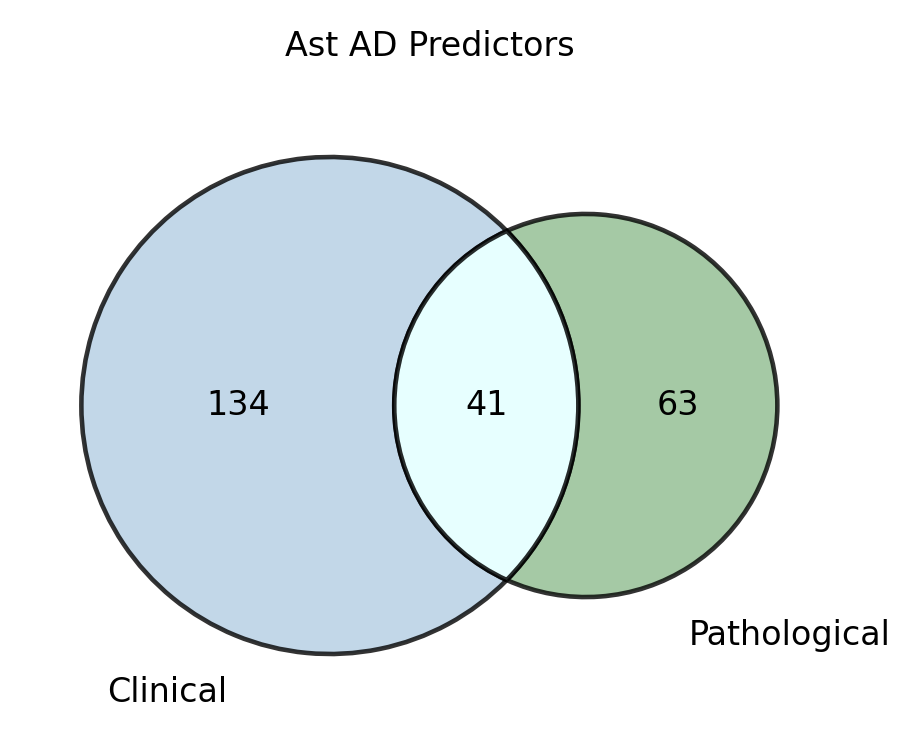

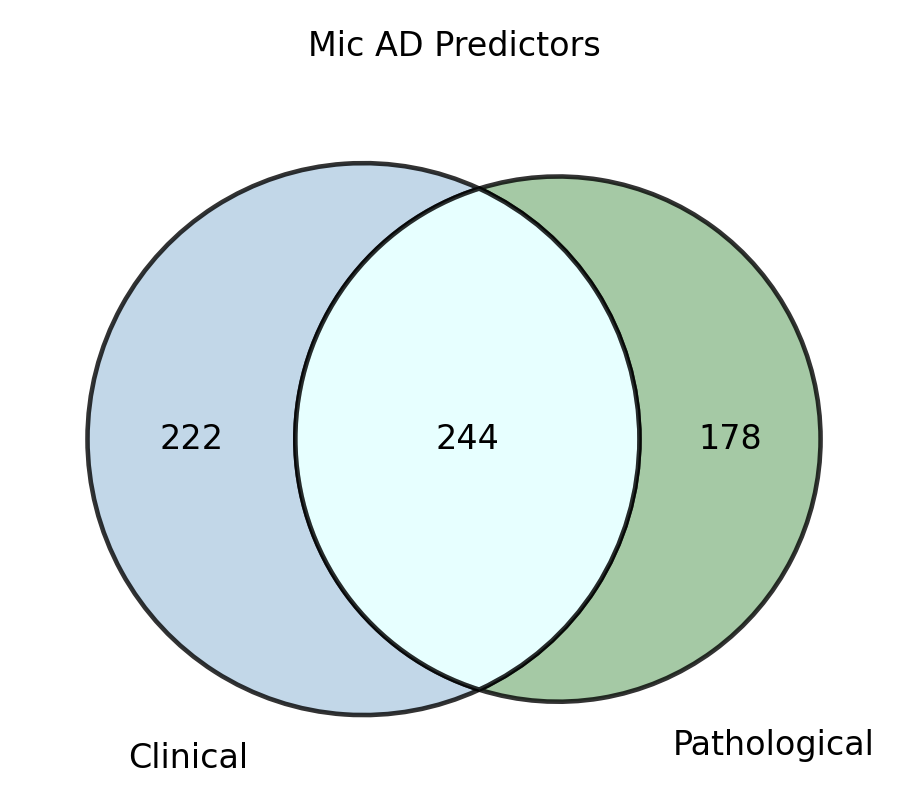

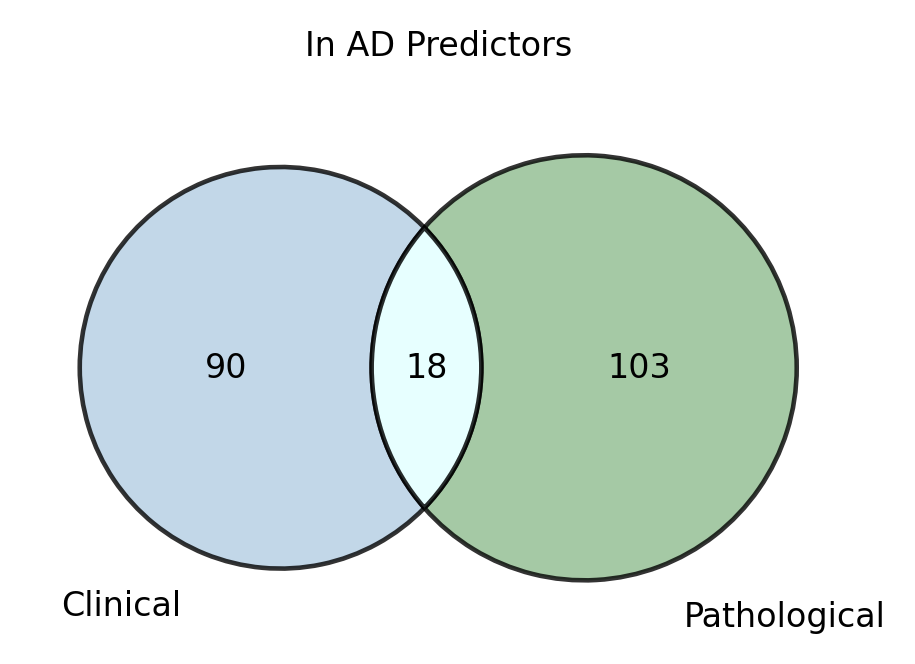

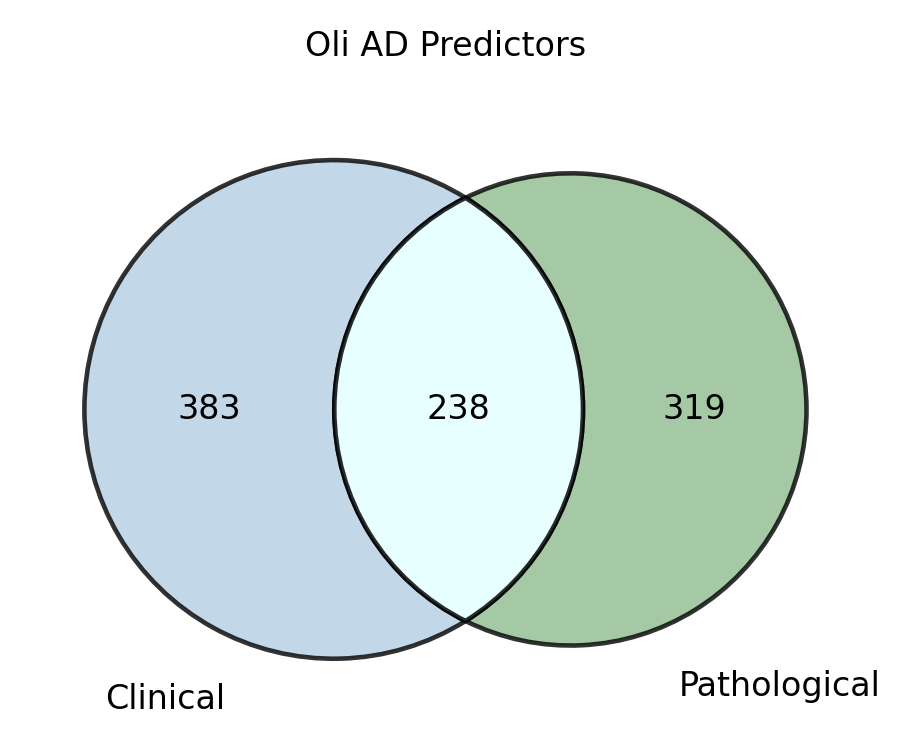

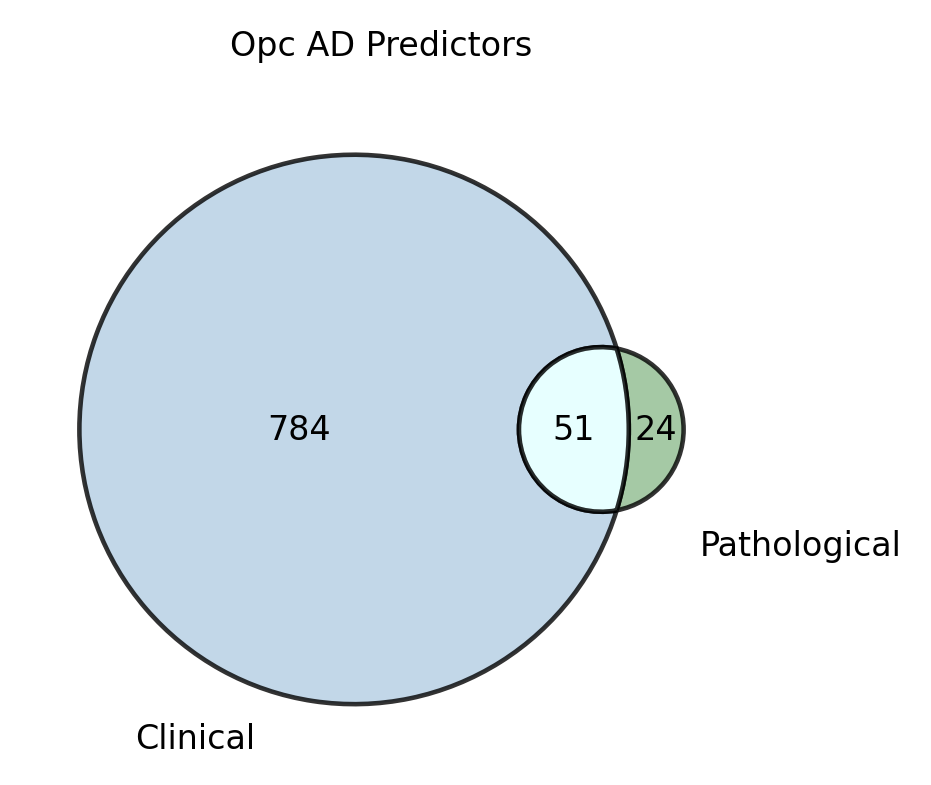

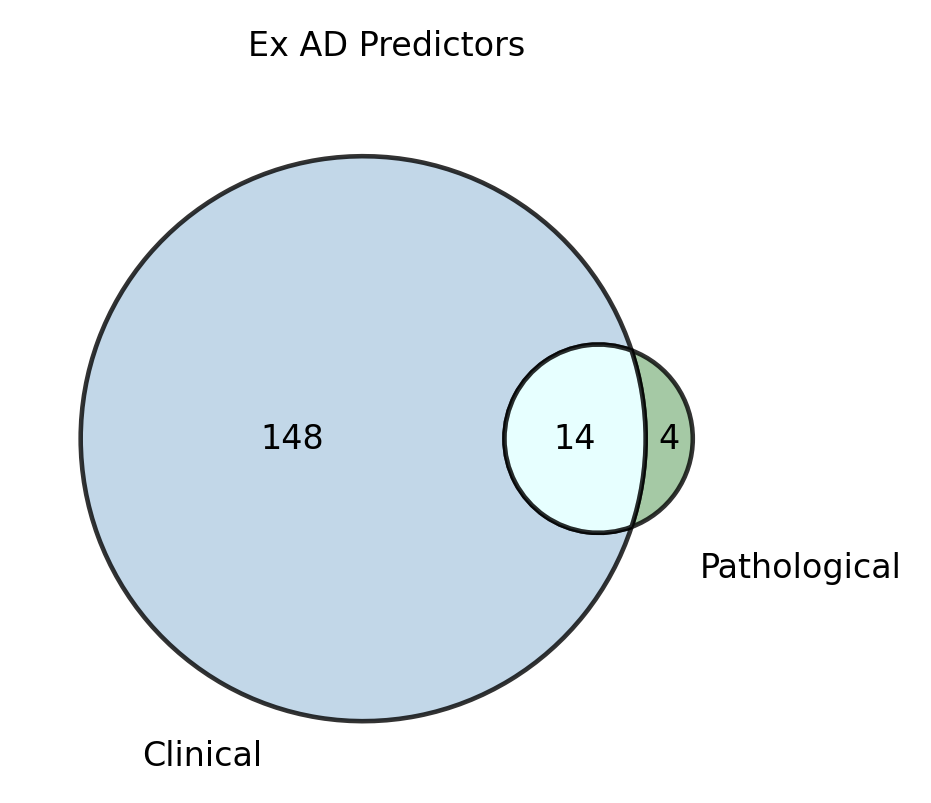

Saved Venn diagrams with zeros hidden.


In [5]:
import pandas as pd

all_celltype_tables = {}

for cell_type in cell_types:
    ad_genes = sorted(set(ad_predictors.get(cell_type, [])))
    cerad_genes = sorted(set(cerad_predictors.get(cell_type, [])))
    # Pad with blanks so both columns are equal length
    max_len = max(len(ad_genes), len(cerad_genes))
    ad_col = ad_genes + [''] * (max_len - len(ad_genes))
    cerad_col = cerad_genes + [''] * (max_len - len(cerad_genes))
    df = pd.DataFrame({
        f'{ct_labels[cell_type]} AD Predictors': ad_col,
        f'{ct_labels[cell_type]} CERAD Predictors': cerad_col
    })
    all_celltype_tables[cell_type] = df

# Concatenate all cell type tables side by side
final_df = pd.concat(list(all_celltype_tables.values()), axis=1)
final_df.to_csv('/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/AD_CERAD_predictive_genes_by_celltype.csv', index=False)
print("Saved as AD_CERAD_predictive_genes_by_celltype.csv")


import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# def neat_venn(set1, set2, label1, label2, title, outpath):
#     if not set1 and not set2:
#         return

#     plt.figure(figsize=(3.2, 3.2), dpi=300, facecolor='white')
#     v = venn2([set1, set2], set_labels=(label1, label2), 
#               set_colors=('#b3cde3', '#8fbc8f'), alpha=0.8)
#     # Black outlines
#     for patch in v.patches:
#         if patch:
#             patch.set_edgecolor('black')
#             patch.set_linewidth(1.1)
#     # Font sizes
#     if v.set_labels[0]:
#         v.set_labels[0].set_fontsize(8)
#     if v.set_labels[1]:
#         v.set_labels[1].set_fontsize(8)
#     # Remove numbers for empty sets or overlap=0, or any subset that's "0"
#     for i, label in enumerate(v.subset_labels):
#         if label and (label.get_text() == '0' or label.get_text() == '0.0'):
#             label.set_text('')
#         if label:
#             label.set_fontsize(8)
#             label.set_color('black')
#     plt.title(title, fontsize=8, pad=12)
#     plt.tight_layout()
#     plt.savefig(outpath, bbox_inches='tight', transparent=False)
#     plt.show()
def neat_venn(set1, set2, label1, label2, title, outpath):
    if not set1 and not set2:
        return

    plt.figure(figsize=(3.2, 3.2), dpi=300, facecolor='white')
    v = venn2([set1, set2], set_labels=(label1, label2), 
              set_colors=('#b3cde3', '#8fbc8f'), alpha=0.8)

    # Black outlines
    for patch in v.patches:
        if patch:
            patch.set_edgecolor('black')
            patch.set_linewidth(1.1)

    # Move set labels outward
    if v.set_labels[0]:
        v.set_labels[0].set_fontsize(8)
        v.set_labels[0].set_x(v.set_labels[0].get_position()[0] - 0.2)  # shift left
    if v.set_labels[1]:
        v.set_labels[1].set_fontsize(8)
        v.set_labels[1].set_x(v.set_labels[1].get_position()[0] + 0.2)  # shift right

    # Remove numbers for empty subsets
    for label in v.subset_labels:
        if label and (label.get_text() == '0' or label.get_text() == '0.0'):
            label.set_text('')
        if label:
            label.set_fontsize(8)
            label.set_color('black')

    plt.title(title, fontsize=8, pad=12)
    plt.tight_layout()
    plt.savefig(outpath, bbox_inches='tight', transparent=False)
    plt.show()

for cell_type in cell_types:
    ad_genes = set(ad_predictors.get(cell_type, []))
    cerad_genes = set(cerad_predictors.get(cell_type, []))
    neat_venn(
        ad_genes,
        cerad_genes,
        label1='Clinical',
        label2='Pathological',
        title=f"{cell_type} AD Predictors",
        outpath=f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/venn_{cell_type}_AD_vs_CERAD.png"
    )

print("Saved Venn diagrams with zeros hidden.")

Total background genes: 17926


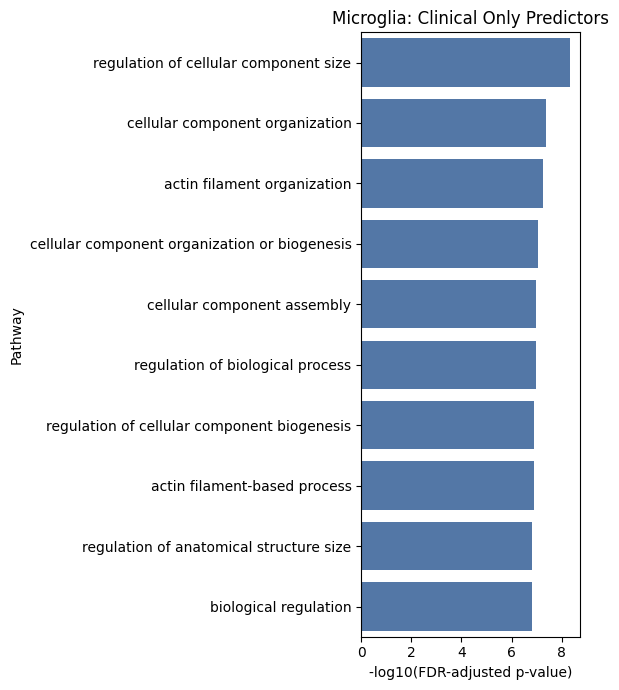

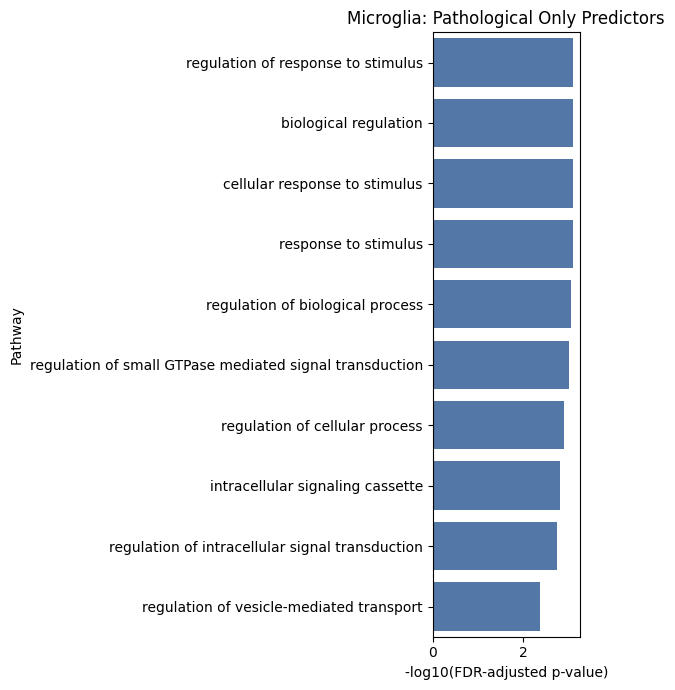

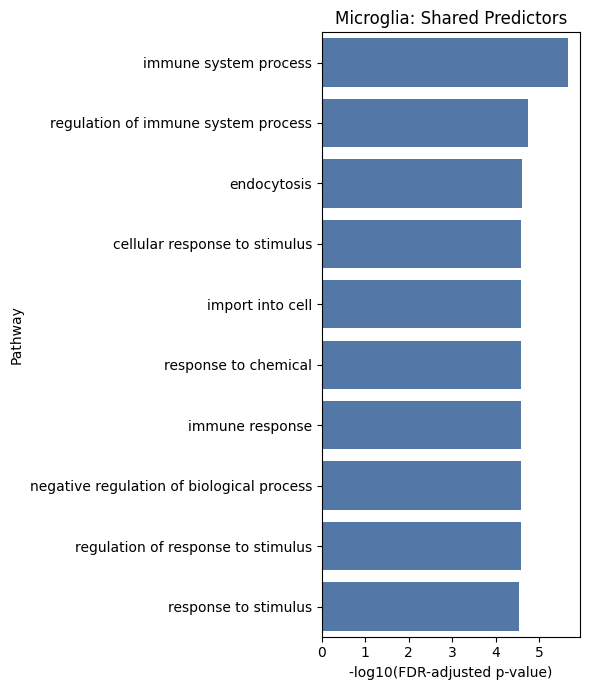

Saved Microglia pathway plots for clinical-only, pathological-only, and shared predictors.


In [14]:
from gprofiler import GProfiler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# === Setup ===
gene_matrix = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet')
background_genes = set(gene_matrix.index.str.upper())
print(f"Total background genes: {len(background_genes)}")

gp = GProfiler(return_dataframe=True)
sources = ['GO:BP']
 # 'GO:BP', 'KEGG', 'REAC', 'WP', 'HP'
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/Pathways/Microglia_Specific"
os.makedirs(out_dir, exist_ok=True)

# === Microglia-specific analysis ===
cell_type = "Mic"
ad_genes = set(ad_predictors.get(cell_type, []))
cerad_genes = set(cerad_predictors.get(cell_type, []))

clin_only = ad_genes - cerad_genes
path_only = cerad_genes - ad_genes
shared = ad_genes & cerad_genes

sets = {
    "Clinical Only": clin_only,
    "Pathological Only": path_only,
    "Shared": shared
}

for label, gene_set in sets.items():
    if not gene_set:
        print(f"[{label}] No genes to analyze.")
        continue

    res = gp.profile(
        organism='hsapiens',
        query=list(gene_set),
        sources=sources,
        no_evidences=True,
        user_threshold=0.05,
        significance_threshold_method="fdr",
        background=list(background_genes)
    )

    if res.empty:
        print(f"[{label}] No significant pathways found.")
        continue

    # Keep top 10 pathways by p-value for visualization
    top_hits = res.nsmallest(10, 'p_value').copy()
    top_hits['-log10(padj)'] = -np.log10(top_hits['p_value'])

    # Plot
    plt.figure(figsize=(6, 4 + 0.3 * len(top_hits)))
    sns.barplot(data=top_hits, x='-log10(padj)', y='name', color="#4575b4")
    plt.xlabel("-log10(FDR-adjusted p-value)")
    plt.ylabel("Pathway")
    plt.title(f"Microglia: {label} Predictors")
    plt.tight_layout()
    filename = os.path.join(out_dir, f"microglia_pathways_{label.replace(' ', '_').lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()

print("Saved Microglia pathway plots for clinical-only, pathological-only, and shared predictors.")

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
from collections import defaultdict
import gseapy as gp

# === Load gene background ===
gene_matrix = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet')
background_genes = set(gene_matrix.index.str.upper())

# === Paths ===
clinical_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
cerad_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
cell_type = 'Mic'  # Focus on Microglia

# === Collect feature importances across splits for both models ===
def get_avg_importances(base_dir, cell_type):
    all_importances = defaultdict(list)

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        for gene, imp in zip(model.feature_names_in_, model.feature_importances_):
            all_importances[gene] += [imp]

    avg_importances = {
        gene: np.mean(imps)
        for gene, imps in all_importances.items()
        if np.count_nonzero(imps) >= 2  # Only keep genes that appear in ≥ 2 splits
    }

    return avg_importances

# === Extract feature importance dictionaries ===
clin_imp = get_avg_importances(clinical_dir, cell_type)
cerad_imp = get_avg_importances(cerad_dir, cell_type)

# === Prepare ranked list (gene, importance) ===
def to_rnk_file(imp_dict, out_path):
    df = pd.DataFrame(list(imp_dict.items()), columns=['gene', 'score'])
    df = df[df['gene'].str.upper().isin(background_genes)]  # Optional: limit to background genes
    df = df.sort_values('score', ascending=False)
    df.to_csv(out_path, sep="\t", index=False, header=False)
    return out_path

clin_rnk_path = f"microglia_clinical_ranked_genes.rnk"
cerad_rnk_path = f"microglia_cerad_ranked_genes.rnk"

to_rnk_file(clin_imp, clin_rnk_path)
to_rnk_file(cerad_imp, cerad_rnk_path)

# === Run GSEA for clinical AD predictors ===



/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

In [4]:
clin_res = gp.prerank(
    rnk=clin_rnk_path,
    gene_sets='GO_Biological_Process_2021',  # or 'KEGG_2021_Human'
    outdir="/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/Pathways/Microglia_Specific/gsea_clinical",  # Output folder
    permutation_num=100,  # Use 1000 for final runs
    min_size=15,
    max_size=500,
    seed=42,
    format='png',
    top_term=20
)

# === Run GSEA for pathological AD (CERAD) predictors ===
cerad_res = gp.prerank(
    rnk=cerad_rnk_path,
    gene_sets='GO_Biological_Process_2021',
    outdir="/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/Pathways/Microglia_Specific/gsea_cerad",
    permutation_num=100,
    min_size=15,
    max_size=500,
    seed=42,
    format='png',
    top_term=20
)

2025-08-01 02:38:48,491 [WARNING] Duplicated values found in preranked stats: 77.66% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-08-01 02:38:48,711 [WARNING] Duplicated values found in preranked stats: 83.45% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


In [5]:
from IPython.display import Image, display
import glob

# === Paths to output folders ===
clinical_plot_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/Pathways/Microglia_Specific/gsea_clinical"
cerad_plot_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/Pathways/Microglia_Specific/gsea_cerad"

# === Display top 5 plots for each ===
def display_top_gsea_plots(folder, title):
    print(f"Showing enrichment plots for: {title}")
    plot_paths = sorted(glob.glob(os.path.join(folder, "gseapy.*.png")))
    
    if not plot_paths:
        print("No plots found.")
        return

    for plot in plot_paths[:5]:
        display(Image(filename=plot))

# === Show clinical and pathological (CERAD) plots ===
display_top_gsea_plots(clinical_plot_dir, "Clinical AD (Microglia)")
display_top_gsea_plots(cerad_plot_dir, "Pathological AD (CERAD, Microglia)")

Showing enrichment plots for: Clinical AD (Microglia)
No plots found.
Showing enrichment plots for: Pathological AD (CERAD, Microglia)
No plots found.



Processing: Microglia


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

Total predictor genes: 422


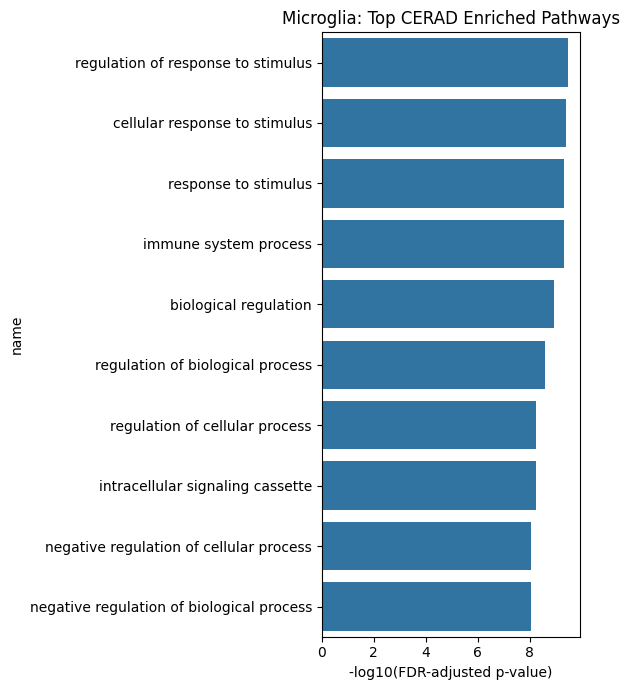

Running Enrichr (DisGeNET) for Microglia
DisGeNET Enrichr failed for Microglia: enrichr is not an attribute of GProfiler

Processing: Oligodendrocytes
Total predictor genes: 557


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w

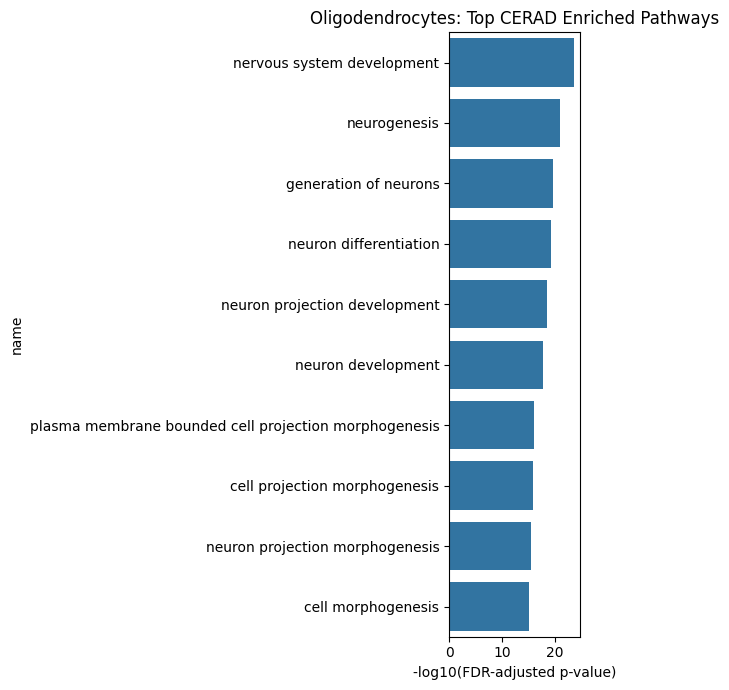

Running Enrichr (DisGeNET) for Oligodendrocytes
DisGeNET Enrichr failed for Oligodendrocytes: enrichr is not an attribute of GProfiler


In [10]:
import os
import joblib
import pandas as pd
import numpy as np
from collections import defaultdict
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

# === Load background genes ===
gene_matrix = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet')
background_genes = set(gene_matrix.index.str.upper())

# === Setup ===
cerad_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
cell_types = {
    'Mic': 'Microglia',
    'Oli': 'Oligodendrocytes'
}
gp = GProfiler(return_dataframe=True)
sources = ['GO:BP', 'KEGG', 'REAC', 'WP', 'HP']
output_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure4/Pathways/CERAD_Enrichment"
os.makedirs(output_dir, exist_ok=True)

# === Extract CERAD predictor genes and run enrichment ===
for ct in cell_types:
    print(f"\nProcessing: {cell_types[ct]}")
    gene_counts = defaultdict(int)

    # Load classifiers and count non-zero genes
    for split in range(1, 6):
        clf_path = os.path.join(cerad_dir, ct, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(clf_path):
            continue
        model = joblib.load(clf_path)
        for gene, imp in zip(model.feature_names_in_, model.feature_importances_):
            if imp > 0:
                gene_counts[gene] += 1

    # Keep genes that are non-zero in ≥2 splits
    predictor_genes = [g for g, c in gene_counts.items() if c >= 2]
    print(f"Total predictor genes: {len(predictor_genes)}")

    if not predictor_genes:
        print("No genes to analyze.")
        continue

    # Run enrichment
    result = gp.profile(
        organism='hsapiens',
        query=predictor_genes,
        sources=sources,
        user_threshold=0.05,
        significance_threshold_method='fdr',
        no_evidences=True,
        background=list(background_genes)
    )

    if result.empty:
        print("No significant pathways found.")
        continue

    # Save full result
    result.to_csv(os.path.join(output_dir, f"{ct}_cerad_enrichment.csv"), index=False)

    # Plot top 10 pathways
    top_hits = result.nsmallest(10, 'p_value').copy()
    top_hits['-log10(padj)'] = -np.log10(top_hits['p_value'])

    plt.figure(figsize=(6, 4 + 0.3 * len(top_hits)))
    sns.barplot(data=top_hits, x='-log10(padj)', y='name', color="#1f77b4")
    plt.title(f"{cell_types[ct]}: Top CERAD Enriched Pathways")
    plt.xlabel("-log10(FDR-adjusted p-value)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{ct}_cerad_pathways.png"), dpi=300)
    plt.show()


    # === Run Enrichr DisGeNET enrichment ===
    print(f"Running Enrichr (DisGeNET) for {cell_types[ct]}")
    try:
        enr = gp.enrichr(
            gene_list=predictor_genes,
            gene_sets='DisGeNET',
            organism='Human',
            outdir=None,  # Do not auto-save to disk
            cutoff=0.05
        )

        if enr.results.empty:
            print("No significant DisGeNET terms.")
        else:
            disgenet_df = enr.results.sort_values("Adjusted P-value").head(10).copy()
            disgenet_df["-log10(padj)"] = -np.log10(disgenet_df["Adjusted P-value"])

            plt.figure(figsize=(6, 4 + 0.3 * len(disgenet_df)))
            sns.barplot(data=disgenet_df, x='-log10(padj)', y='Term', color="#d62728")
            plt.title(f"{cell_types[ct]}: DisGeNET Enrichment (CERAD Predictors)")
            plt.xlabel("-log10(FDR-adjusted p-value)")
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f"{ct}_disgenet_enrichment.png"), dpi=300)
            plt.show()

            disgenet_df.to_csv(os.path.join(output_dir, f"{ct}_disgenet_enrichment.csv"), index=False)

    except Exception as e:
        print(f"DisGeNET Enrichr failed for {cell_types[ct]}: {e}")

IndentationError: unexpected indent (51587178.py, line 4)